In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load features
with open("../data/all_features.pkl", "rb") as f:
    all_features = pickle.load(f)

ASSETS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'SPY', 'GLD']
print("Data loaded!")
print("Sample AAPL shape:", all_features['AAPL'].shape)

Data loaded!
Sample AAPL shape: (1458, 19)


In [3]:
ASSETS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'SPY', 'GLD']

def train_model(asset, all_features, train_ratio=0.8):
    df = all_features[asset].dropna()
    
    feature_cols = [c for c in df.columns if c != 'target']
    X = df[feature_cols]
    y = df['target']
    
    split = int(len(df) * train_ratio)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{asset} → RMSE: {rmse:.6f}")
    
    return model, y_pred, y_test, X_test

# Train for all assets
models = {}
predictions = {}

for asset in ASSETS:
    model, y_pred, y_test, X_test = train_model(asset, all_features)
    models[asset] = model
    predictions[asset] = {'y_pred': y_pred, 'y_test': y_test}

AAPL → RMSE: 0.015262
MSFT → RMSE: 0.017342
NVDA → RMSE: 0.031679
JPM → RMSE: 0.013380
SPY → RMSE: 0.009412
GLD → RMSE: 0.009665


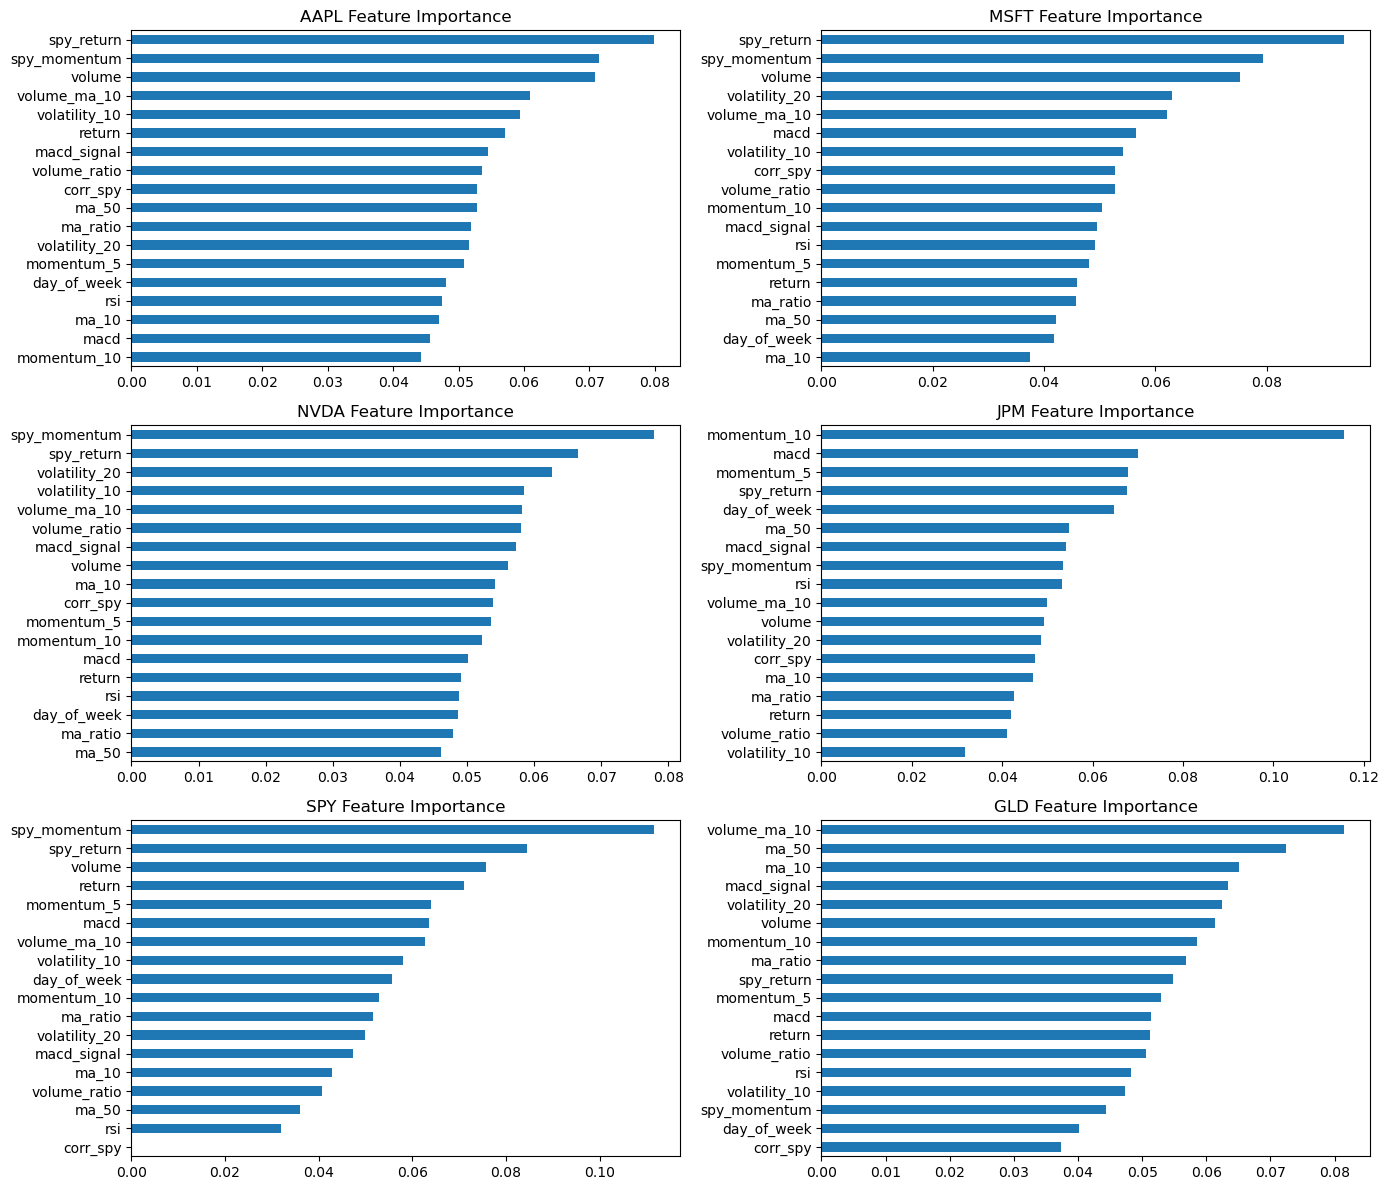

In [4]:
# Feature importance for each asset
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, asset in enumerate(ASSETS):
    importance = pd.Series(
        models[asset].feature_importances_,
        index=[c for c in all_features[asset].columns if c != 'target']
    ).sort_values(ascending=True)
    
    importance.plot(kind='barh', ax=axes[i], title=f'{asset} Feature Importance')

plt.tight_layout()
plt.show()

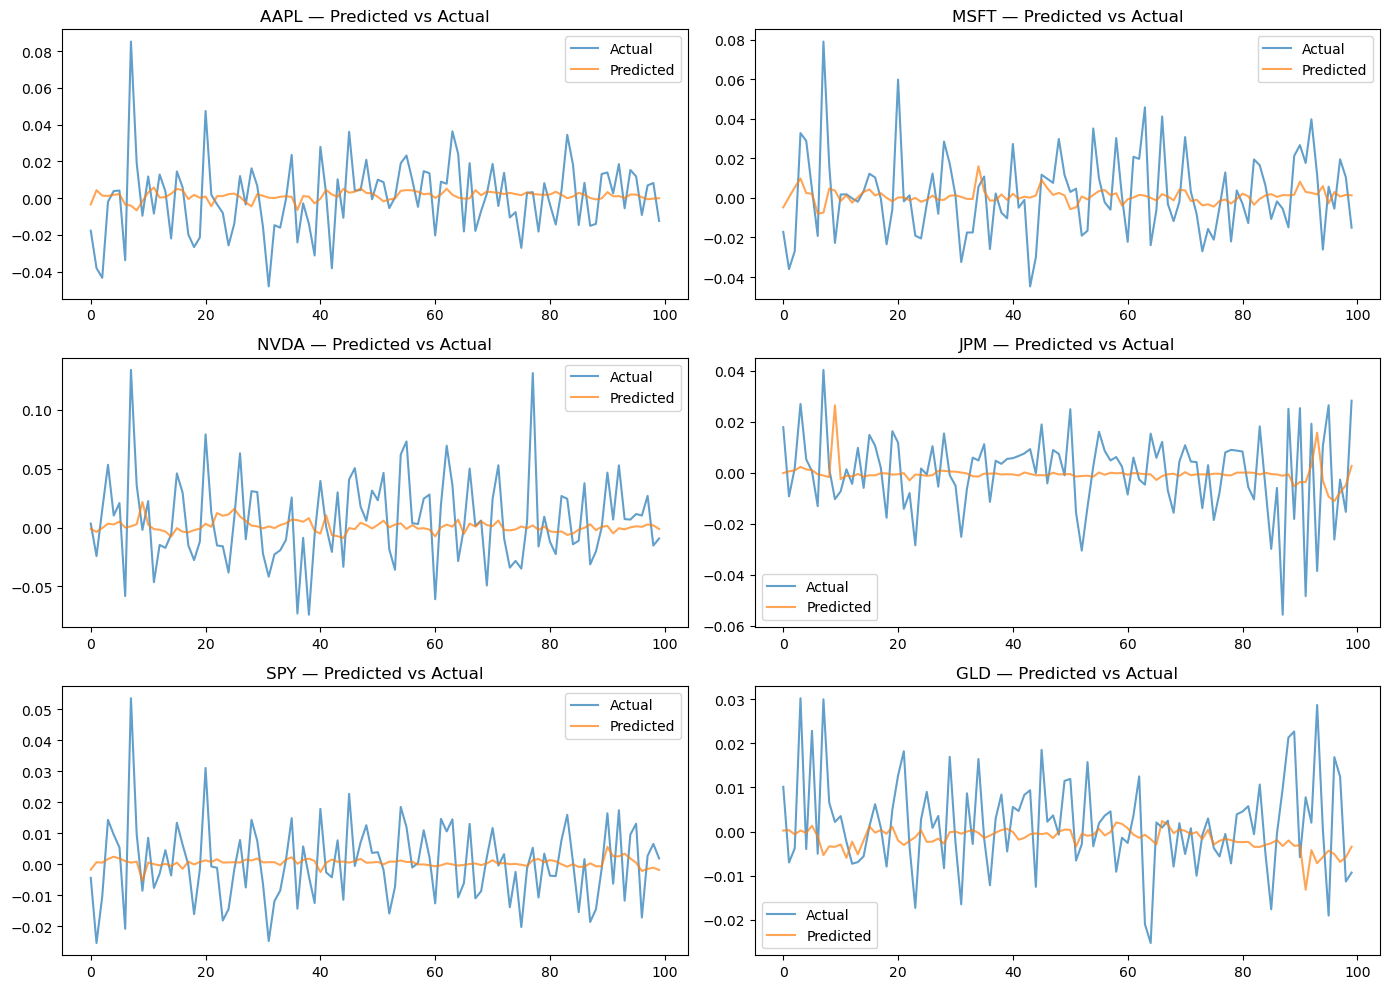

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, asset in enumerate(ASSETS):
    y_test = predictions[asset]['y_test']
    y_pred = predictions[asset]['y_pred']
    
    axes[i].plot(y_test.values[:100], label='Actual', alpha=0.7)
    axes[i].plot(y_pred[:100], label='Predicted', alpha=0.7)
    axes[i].set_title(f'{asset} — Predicted vs Actual')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [6]:
with open("../data/models.pkl", "wb") as f:
    pickle.dump(models, f)

with open("../data/predictions.pkl", "wb") as f:
    pickle.dump(predictions, f)

print("Models and predictions saved!")

Models and predictions saved!
